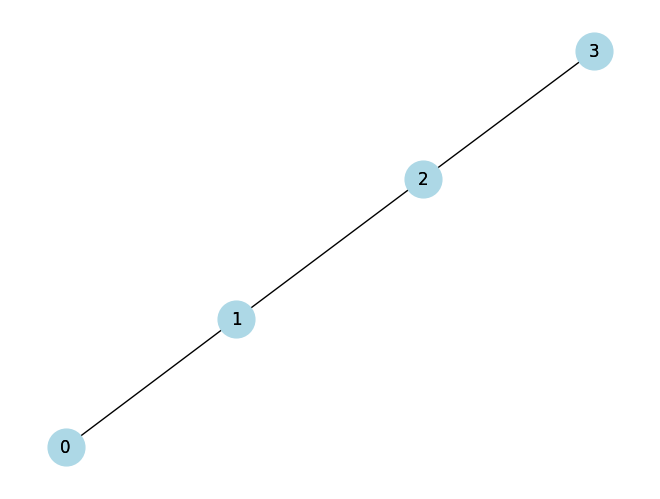

In [1]:
from qrisp import QuantumVariable
from qrisp.vqe.problems.heisenberg import *
import matplotlib.pyplot as plt
import networkx as nx

# 1. Define your qubit graph (e.g., 1D chain, 4 qubits, XXX coupling)
# Create a graph - lattice structure of spins
G = nx.Graph()
G.add_edges_from([(0,1),(1,2),(2,3)])

# Draw the graph with labels
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue')
nx.draw_networkx_labels(G, pos)
plt.show()

In [8]:
import numpy as np
# 2. Set interaction parameters
J = 1.0  # interaction strength
B = 1.0  # transverse field strength

# 3. Create the Problem Hamiltonian (H_problem)
H_problem = create_heisenberg_hamiltonian(G, J, B)
print("Problem Hamiltonian:", H_problem)

J_target = 4
B_target = 4
# J_target = 1 + np.random.rand()
# B_target = 1 + np.random.rand()


# Create the Target Hamiltonian (H_target)
H_target = create_heisenberg_hamiltonian(G, J_target, B_target)
print(f"Target Hamiltonian: {H_target}")
# print(H_problem

Problem Hamiltonian: 1.0*X(0)*X(1) + 1.0*X(1)*X(2) + 1.0*X(2)*X(3) + 1.0*Y(0)*Y(1) + 1.0*Y(1)*Y(2) + 1.0*Y(2)*Y(3) + 1.0*Z(0) + 1.0*Z(0)*Z(1) + 1.0*Z(1) + 1.0*Z(1)*Z(2) + 1.0*Z(2) + 1.0*Z(2)*Z(3) + 1.0*Z(3)
Target Hamiltonian: 4*X(0)*X(1) + 4*X(1)*X(2) + 4*X(2)*X(3) + 4*Y(0)*Y(1) + 4*Y(1)*Y(2) + 4*Y(2)*Y(3) + 4*Z(0) + 4*Z(0)*Z(1) + 4*Z(1) + 4*Z(1)*Z(2) + 4*Z(2) + 4*Z(2)*Z(3) + 4*Z(3)


In [9]:
E0_problem = H_problem.ground_state_energy()
print("Exact ground-state energy:", E0_problem)
E0_target = H_target.ground_state_energy()
print("Exact ground-state energy (target):", E0_target)

Exact ground-state energy: -6.4641016151377535
Exact ground-state energy (target): -25.856406460551057


In [ ]:
# from qrisp.linalg import eigsh

# convert Hamiltonian to sparse matrix format
H_problem_matrix = H_problem.to_sparse_matrix()

from scipy.sparse.linalg import eigsh

# find the GS energy and GS quantum state from the problem Hamiltonian
eigvals, eigvecs = eigsh(H_problem_matrix, k=1, which='SA') # get the smallest eigenvalue and eigenvector 
exact_GS_energy = eigvals[0]
exact_ground_state = eigvecs[:, 0]

print("Exact ground state energy:", exact_GS_energy.real) # surpress floating point errors on imaginary parts (which shouldn't exist anyway)
print("Exact ground state vector:", exact_ground_state)

ModuleNotFoundError: No module named 'qrisp.linalg'

In [ ]:
import os, json

from quantum_models import quixer_ansatz, quixer_params_per_layer, build_magnetization_penalty


def run_experiment(ansatz_type, depth):
    print(f"(ansatz_type: {ansatz_type}, depth: {depth})")
    # Optional spin-adaptation penalty
    lam = float(os.environ.get('VQE_LAMBDA_MAG2', '0.0'))
    H_eff = build_magnetization_penalty(H_problem, lambda_penalty=lam)

    if ansatz_type == 'quixer':
        # Manual VQEProblem with Quixer-inspired layer
        from qrisp.vqe import VQEProblem
        n_params = quixer_params_per_layer(G.number_of_nodes())
        def ansatz(qv, theta):
            for _ in range(depth):
                quixer_ansatz(qv, theta)
        vqe = VQEProblem(hamiltonian=H_eff, ansatz_function=ansatz, num_params=n_params)
    else:
        # Built-in heisenberg_problem
        vqe = heisenberg_problem(G, J, B, ansatz_type=ansatz_type)
    vqe.set_callback()
    precision = float(os.environ.get('VQE_PRECISION', '0.005'))
    energy = vqe.run(
        QuantumVariable(G.number_of_nodes()),
        depth,
        max_iter=int(os.environ.get('VQE_MAX_ITER', '100')),
        mes_kwargs={'precision': precision},
    )
    return energy

# Environment-driven filtering for parallel orchestration
_ansatz_env = os.environ.get('VQE_ANSATZ_FILTER', 'trotter,per_hamiltonian,hardware_efficient,quixer')
_ansatz_filter = {x.strip() for x in _ansatz_env.split(',') if x.strip()}
_depths_env = os.environ.get('VQE_DEPTHS_JSON') or os.environ.get('VQE_DEPTHS', '')

def _parse_depths(val):
    if not val:
        return [1, 2, 3, 4, 5]
    try:
        arr = json.loads(val)
        if isinstance(arr, list):
            return [int(x) for x in arr]
    except Exception:
        pass
    if ':' in val:
        try:
            start, stop, step = (int(x) for x in val.split(':'))
            return list(range(start, stop, step))
        except Exception:
            pass
    try:
        return [int(x) for x in val.split(',') if x.strip()]
    except Exception:
        return [1, 2, 3, 4, 5]

# Number of HEA layers / Trotter steps
depths = _parse_depths(_depths_env)

energies_trotter = [run_experiment(ansatz_type="trotter", depth=d) for d in depths] if ("trotter" in _ansatz_filter) else None
energies_hva = [run_experiment(ansatz_type="per_hamiltonian", depth=d) for d in depths] if ("per_hamiltonian" in _ansatz_filter) else None
energies_hea = [run_experiment(ansatz_type="hardware_efficient", depth=d) for d in depths] if ("hardware_efficient" in _ansatz_filter) else None
energies_quixer = [run_experiment(ansatz_type="quixer", depth=d) for d in depths] if ("quixer" in _ansatz_filter) else None

(ansatz_type: trotter, depth: 1)
Simulating 4 qubits.. |                                                      | [  0%]

(ansatz_type: trotter, depth: 2)                                                     
(ansatz_type: trotter, depth: 3)                                                     
(ansatz_type: trotter, depth: 4)                                                     
(ansatz_type: trotter, depth: 5)                                                     
(ansatz_type: per_hamiltonian, depth: 1)                                             
(ansatz_type: per_hamiltonian, depth: 2)                                             
(ansatz_type: per_hamiltonian, depth: 3)                                             
(ansatz_type: per_hamiltonian, depth: 4)                                             
(ansatz_type: per_hamiltonian, depth: 5)                                             
(ansatz_type: hardware_efficient, depth: 1)                                          
(ansatz_type: hardware_efficient, depth: 2)                                          
(ansatz_type: hardware_efficient, depth: 3)           

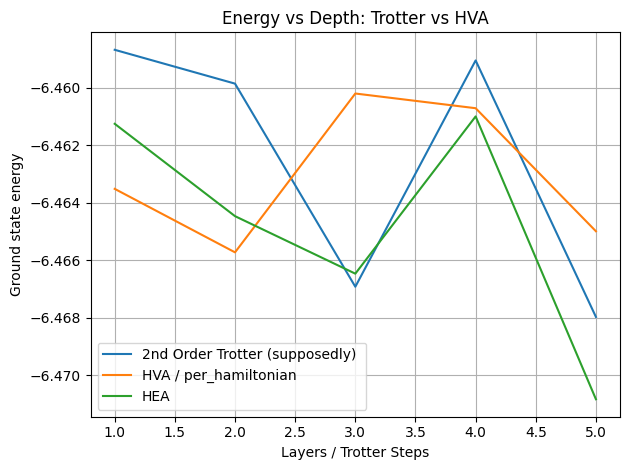

In [ ]:
# Robust plotting: only plot series that were computed in this run
import matplotlib.pyplot as plt

series = []
if 'energies_trotter' in globals() and energies_trotter is not None:
    series.append(("2nd Order Trotter (supposedly)", energies_trotter))
if 'energies_hva' in globals() and energies_hva is not None:
    series.append(("HVA / per_hamiltonian", energies_hva))
if 'energies_hea' in globals() and energies_hea is not None:
    series.append(("HEA", energies_hea))
if 'energies_quixer' in globals() and energies_quixer is not None:
    series.append(("Quixer-inspired", energies_quixer))

plotted = 0
for label, ys in series:
    try:
        if ys is None:
            continue
        if len(ys) == len(depths) and len(ys) > 0:
            plt.plot(depths, ys, label=label)
            plotted += 1
        elif len(ys) > 0:
            plt.plot(list(range(len(ys))), ys, label=label)
            plotted += 1
    except Exception as e:
        print(f"[WARN] Skipping series '{label}' due to error: {e}")

plt.xlabel("Layers / Trotter Steps")
plt.ylabel("Ground state energy")
plt.title("Energy vs Depth: Trotter vs HVA")
if plotted > 0:
    plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Trying heisenberg_problem with my own ansatzs

In [ ]:
from qrisp.vqe import VQEProblem
#from vqe_core.ansatz_builders import build_2nd_order_trotter_ansatz
from sympy import Symbol

# Build Trotter ansatz
# ansatz_fn, n_params, init_fn = build_2nd_order_trotter_ansatz(H_target, n_steps=5)  # 4 Trotter steps)
#print(ansatz_fn)

n_qubits = 4

from qrisp import QuantumVariable
# Step 1: create n parameter symbols
n_trotter_steps = 2
# theta_symbols = symbols(f"t0:{n_trotter_steps}")  # yields (t0, t1, t2, t3, t4)

# Step 2: create the trotter evolution wrapper
evol = H_target.trotterization(order=2, method="commuting", forward_evolution=True)

# Step 3: define your ansatz function binding one symbol per Trotter layer
def trotter_ansatz_fn(qv: QuantumVariable, theta):
    assert len(theta) == n_trotter_steps
    for ti in theta:
        evol(qv, t=ti, steps=1)  # each ti binds to a single layer

# 2. Define a 2-local ansatz layer (rotation + entanglement)
from qrisp import ry, rz, cx

def twolocal_ansatz(qv, theta):
    n = qv.size  # number of qubits
    # Single-qubit rotations
    for i in range(n):
        qubit = qv[i]
        ry(theta[i], qubit)
        rz(theta[n + i], qubit)
    # Linear entanglers
    for i in range(n - 1):
        cx(qv[i], qv[i + 1])

# Create a VQEProblem manually
vqe = VQEProblem(
    hamiltonian=H_problem,            # Qrisp QubitOperator
    ansatz_function=twolocal_ansatz,  # function with signature (qv, params)
    num_params=8,      # number of parameters per layer
    #init_function=init_fn,       # optional function to set initial state
    callback=True             # collect intermediate fidelity/energy if needed
)

# Then compile the circuit for inspection:
qv = QuantumVariable(n_qubits)
compiled_qc, param_symbols = vqe.compile_circuit(qv, depth=1)

energy = vqe.run(
    qarg=qv,                   # QuantumVariable or callable returning one
    depth=8,               # number of ansatz layers
    mes_kwargs={'precision': 0.01},  # measurement config
    max_iter=1000,              # maximum classical optimization iterations
    init_type='random',        # parameter initialization style
    optimizer='COBYLA',        # optimization algorithm
    options={}                 # any additional optimizer options
)
print(f"Energy: {energy}")

Simulating 4 qubits.. |                                                      | [  0%]

Energy: -6.272823366661424                                                           


NameError: name 'theta' is not defined

In [8]:
# 2. Run benchmark
benchmark = vqe.benchmark(
    qv,
    depth_range = [1,2,3,4,5,6],              # test various circuit depths
    precision_range = [0.005],  # different shot noises / measurement precisions
    iter_range = [1000],           # limit on classical steps
    optimal_energy = E0_problem,
    repetitions = 4                          # independent random seeds
)

# 3. Visualize and inspect results
benchmark.visualize()

NameError: name 'vqe' is not defined

In [9]:
for i in range(10):
    energy = vqe.run(
        qarg=qv,                   # QuantumVariable or callable returning one
        depth=8,               # number of ansatz layers
        mes_kwargs={'precision': 0.01},  # measurement config
        max_iter=1000,              # maximum classical optimization iterations
        init_type='random',        # parameter initialization style
        optimizer='COBYLA',        # optimization algorithm
        options={}                 # any additional optimizer options
    )
    print(f"Energy {i}: {energy}")
# print(theta)

NameError: name 'vqe' is not defined

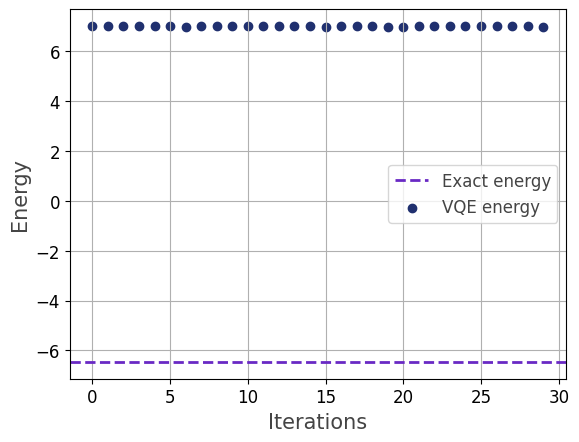

AssertionError: 

In [ ]:
# data = vqe.get_callback_data()
# print("Initial theta:", data['theta_seq'][0])
# print("Final theta:", data['theta_seq'][-1])
# print("Energy progression:", data['energy_seq'])

# Visualize, if available
try:
    vqe.visualize_energy(exact=True)
    benchmark_data = vqe.benchmark(
        qarg=lambda: QuantumVariable(n_qubits),
        depth_range=[1],
        precision_range=[0.01],
        iter_range=[1000],
        optimal_energy=H_problem.ground_state_energy(),
        repetitions=2,
    )
    benchmark_data.visualize()
except NameError:
    print("[WARN] vqe is not defined; skipping visualization/benchmark.")
except Exception as exc:
    print(f"[WARN] visualization/benchmark failed: {exc}")

In [ ]:
import numpy as np
from scipy.optimize import minimize
from sympy import symbols

# Step 1: create n parameter symbols
n_trotter_steps = 10
theta_symbols = symbols(f"t0:{n_trotter_steps}")  # yields (t0, t1, t2, t3, t4)

# Step 2: create the trotter evolution wrapper
evol = H_target.trotterization(order=2, method="commuting", forward_evolution=True)

# Step 3: define your ansatz function binding one symbol per Trotter layer
def trotter_ansatz_fn(qv: QuantumVariable, theta):
    assert len(theta) == n_trotter_steps
    for ti in theta:
        evol(qv, t=ti, steps=1)  # each ti binds to a single layer

# Example usage:
print(theta_symbols)  # -> show list of theta_symbols: (t0, t1, ..., t4)
qv = QuantumVariable(n_qubits) # initiate quantum state (based on n_qubits)
trotter_ansatz_fn(qv, theta_symbols)

print(qv.qs)  # inspect to see symbolic 'ti' in the gate angles. 
                # Show the ansatz with parameters binded to it

# create the trotter ansatz
ansatz_fn = trotter_ansatz_fn(qv, theta_symbols)

# 3. Build expectation-value function via Qrisp API
def build_ev_fn(H, ansatz_fn, n_qubits):
    def state_prep(theta):
        qv = QuantumVariable(n_qubits)
        ansatz_fn(qv, theta)
        # print(qv.qs)
        return qv
    return H.expectation_value(
        state_prep,
        precision=0.01,
        diagonalisation_method="commuting"
    )

ev_fn = build_ev_fn(H_problem, ansatz_fn, n_qubits=4)

# 4. Classical optimizer loop
theta0 = np.random.rand(n_trotter_steps) * 0.1 
#* 2 * np.pi
# res = minimize(lambda th: ev_fn(th), theta0, method='COBYLA')

print(f"ev_fn: {ev_fn}")
res = minimize(
    lambda th: ev_fn(th),
    theta0,
    method="L-BFGS-B",
    options={"maxiter":1000}
)
print(f"ev_fn: {ev_fn}")

print("Optimized energy:", res.fun)
print("Optimized parameters:", res.x)

NameError: name 'symbols' is not defined

In [ ]:
from sympy import symbols
from qrisp import QuantumVariable

# Step 1: create n parameter symbols
n_trotter_steps = 2
theta_symbols = symbols(f"t0:{n_trotter_steps}")  # yields (t0, t1, t2, t3, t4)

# Step 2: create the trotter evolution wrapper
evol = H_target.trotterization(order=2, method="commuting", forward_evolution=True)

# Step 3: define your ansatz function binding one symbol per Trotter layer
def trotter_ansatz_fn(qv: QuantumVariable, theta):
    assert len(theta) == n_trotter_steps
    for ti in theta:
        evol(qv, t=ti, steps=1)  # each ti binds to a single layer

# Example usage:
print(theta_symbols)  # -> (t0, t1, ..., t4)

qv = QuantumVariable(n_qubits)
trotter_ansatz_fn(qv, theta_symbols)
print(qv.qs)  # inspect to see symbolic 'ti' in the gate angles

(t0, t1)
QuantumCircuit:
---------------
      ┌───┐┌───┐┌──────────┐┌───┐     ┌───┐                                   »
qv.0: ┤ H ├┤ H ├┤ Rz(4*t0) ├┤ H ├─────┤ H ├───────────────────────────────────»
      └───┘└───┘└──┬───┬───┘└───┘     └───┘          ┌──────────┐┌───┐   ┌───┐»
qv.1: ───────■─────┤ H ├──────■───────────────────■──┤ Rz(4*t0) ├┤ H ├─■─┤ H ├»
      ┌───┐  │     ├───┤    ┌─┴─┐┌─────────────┐┌─┴─┐├──────────┤├───┤ │ ├───┤»
qv.2: ┤ H ├──■─────┤ H ├────┤ X ├┤ Rz((-4)*t0) ├┤ X ├┤ Rz(4*t0) ├┤ H ├─■─┤ H ├»
      ├───┤┌───┐┌──┴───┴───┐├───┤└────┬───┬────┘├───┤└──────────┘└───┘   └───┘»
qv.3: ┤ H ├┤ H ├┤ Rz(4*t0) ├┤ H ├─────┤ H ├─────┤ H ├─────────────────────────»
      └───┘└───┘└──────────┘└───┘     └───┘     └───┘                         »
«         ┌───┐                         ┌──────────┐┌───┐             »
«qv.0: ─■─┤ H ├──■───────────────────■──┤ Rz(4*t0) ├┤ H ├─■───────────»
«       │ ├───┤┌─┴─┐┌─────────────┐┌─┴─┐├──────────┤├───┤ │ ┌───┐┌───┐»
«qv.1: ─■─┤ H ├┤ X ├┤ R

In [ ]:
from sympy import symbols
from qrisp import QuantumVariable

n_trotter_steps = 2
theta_symbols = symbols(f"t0:{n_trotter_steps}")  # e.g. (t0, t1)

evol = H_target.trotterization(order=2, method="commuting", forward_evolution=True)

def trotter_ansatz_fn(qv: QuantumVariable, theta):
    assert len(theta) == n_trotter_steps
    for ti in theta:
        evol(qv, t=ti, steps=1)

# Example usage:
qv = QuantumVariable(n_qubits)
trotter_ansatz_fn(qv, theta_symbols)
print(theta_symbols)
print(qv.qs)

(t0, t1)
QuantumCircuit:
---------------
      ┌───┐┌───┐┌──────────┐┌───┐     ┌───┐                                   »
qv.0: ┤ H ├┤ H ├┤ Rz(4*t0) ├┤ H ├─────┤ H ├───────────────────────────────────»
      └───┘└───┘└──┬───┬───┘└───┘     └───┘          ┌──────────┐┌───┐   ┌───┐»
qv.1: ───────■─────┤ H ├──────■───────────────────■──┤ Rz(4*t0) ├┤ H ├─■─┤ H ├»
      ┌───┐  │     ├───┤    ┌─┴─┐┌─────────────┐┌─┴─┐├──────────┤├───┤ │ ├───┤»
qv.2: ┤ H ├──■─────┤ H ├────┤ X ├┤ Rz((-4)*t0) ├┤ X ├┤ Rz(4*t0) ├┤ H ├─■─┤ H ├»
      ├───┤┌───┐┌──┴───┴───┐├───┤└────┬───┬────┘├───┤└──────────┘└───┘   └───┘»
qv.3: ┤ H ├┤ H ├┤ Rz(4*t0) ├┤ H ├─────┤ H ├─────┤ H ├─────────────────────────»
      └───┘└───┘└──────────┘└───┘     └───┘     └───┘                         »
«         ┌───┐                         ┌──────────┐┌───┐             »
«qv.0: ─■─┤ H ├──■───────────────────■──┤ Rz(4*t0) ├┤ H ├─■───────────»
«       │ ├───┤┌─┴─┐┌─────────────┐┌─┴─┐├──────────┤├───┤ │ ┌───┐┌───┐»
«qv.1: ─■─┤ H ├┤ X ├┤ R

In [ ]:
# Variational bound guard: verify VQE results are not below exact ground energy
from qrisp_utils import (
    compute_exact_ground_energy,
    validate_and_fix,
)
from qrisp.vqe.problems.heisenberg import heisenberg_problem
from qrisp import QuantumVariable

try:
    exact_E = compute_exact_ground_energy(H_problem)
    print(f"Exact ground-state energy (recomputed): {exact_E}")
except Exception as exc:
    print(f"[WARN] exact energy recompute failed: {exc}")
    exact_E = H_problem.ground_state_energy()


def ensure_variational_bound_for_series(ansatz_type, energies, depths):
    if energies is None:
        return
    print(f"\nChecking ansatz_type={ansatz_type} across depths={depths}")

    for d, E in zip(depths, energies):
        if E < exact_E - (1e-6 + abs(exact_E) * 1e-8):
            print(f"[VIOLATION] depth={d}: estimate={E:.6f} < exact={exact_E:.6f}")
            result = validate_and_fix(
                vqe_supplier=lambda: heisenberg_problem(G, J, B, ansatz_type=ansatz_type),
                hamiltonian=H_problem,
                qarg_supplier=lambda: QuantumVariable(G.number_of_nodes()),
                depth=d,
                energy_estimate=E,
                precision_schedule=(0.005, 0.0025, 0.001),
                max_iter=250,
                optimizer="COBYLA",
            )
            print(
                f"  -> fixed_valid={result.is_valid}, energy={result.estimated_energy:.6f}, "
                f"exact={result.exact_energy:.6f}, margin={result.violation_margin:.3e}, "
                f"precision_used={result.precision_used}, details={result.details}"
            )
        else:
            print(f"[OK] depth={d}: estimate={E:.6f} >= exact={exact_E:.6f}")


# Guard for the three series if present
try:
    _depths = depths
except NameError:
    _depths = []

try:
    ensure_variational_bound_for_series("trotter", energies_trotter, _depths)
except NameError:
    pass

try:
    ensure_variational_bound_for_series("per_hamiltonian", energies_hva, _depths)
except NameError:
    pass

try:
    ensure_variational_bound_for_series("hardware_efficient", energies_hea, _depths)
except NameError:
    pass

try:
    ensure_variational_bound_for_series("quixer", energies_quixer, _depths)
except NameError:
    pass

# Also validate the last scalar 'energy' from the custom VQEProblem if available
try:
    if 'energy' in globals():
        print("\nChecking custom VQEProblem energy:")
        res = validate_and_fix(
            vqe_supplier=lambda: vqe,
            hamiltonian=H_problem,
            qarg_supplier=lambda: QuantumVariable(G.number_of_nodes()),
            depth=8,
            energy_estimate=float(energy),
            precision_schedule=(0.01, 0.005, 0.0025),
            max_iter=500,
            optimizer="COBYLA",
        )
        print(
            f"  custom_vqe_valid={res.is_valid}, energy={res.estimated_energy:.6f}, "
            f"exact={res.exact_energy:.6f}, margin={res.violation_margin:.3e}, details={res.details}"
        )
except Exception as exc:
    print(f"[WARN] custom VQE validation failed: {exc}")


In [ ]:
# GQE (Generative Quantum Eigensolver) minimal pipeline
from gqe import (
    extract_graph_heisenberg_features,
    init_quixer_params,
    quixer_predict,
    make_trotter_ansatz,
    run_gqe,
)

E_gqe, gqe_info = run_gqe(G, H_problem, J=J, B=B, steps_max=8, seed=0)
print(f"GQE estimated energy: {E_gqe}")
print(gqe_info)
